In [1]:
# ============================================================
# SECTION A  –  Imports & Helper Utilities

In [2]:
# ============================================================

import os
import json
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pandas as pd

import tensorflow as tf
from sklearn.metrics import accuracy_score

In [3]:
# ── Colour palette (matches the rest of the notebook) ────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({"figure.dpi": 120, "font.family": "DejaVu Sans",
                     "axes.titlesize": 14, "axes.labelsize": 12})
ACCENT  = "#7C3AED"
ACCENT2 = "#06B6D4"
RED     = "#EF4444"
GREEN   = "#22C55E"
AMBER   = "#F59E0B"

In [4]:
# ============================================================
# SECTION A2  –  Load everything from disk
# ============================================================
# This script runs as its own separate process, so it can't see variables
# from tuner_results.py or hyperparameter_tuning.py — those only exist in
# THAT script's memory while it's running. We reload what we need here.

TEST_DATA_PATH = "test_data.npz"
META_PATH       = "model_meta.json"

if not os.path.exists(TEST_DATA_PATH) or not os.path.exists(META_PATH):
    raise FileNotFoundError(
        f"Expected '{TEST_DATA_PATH}' and '{META_PATH}' in the current directory. "
        "These are saved automatically at the end of tuner_results.py "
        "(or hyperparameter_tuning.py) — run that script first, then run "
        "this one from the same folder."
    )

print("Loading test set and metadata from disk …")
test_data = np.load(TEST_DATA_PATH)
X_test, y_test = test_data["X_test"], test_data["y_test"]

with open(META_PATH) as f:
    meta = json.load(f)
actions          = meta["actions"]
num_classes      = meta["num_classes"]
MODEL_SAVE_PATH  = meta["model_save_path"]

print(f"  X_test: {X_test.shape}  y_test: {y_test.shape}")
print(f"  {num_classes} classes, model path: {MODEL_SAVE_PATH}\n")

Loading test set and metadata from disk …
  X_test: (440, 30, 447)  y_test: (440, 40)
  40 classes, model path: models/signlingo_gru_best.h5



In [5]:
# ── Variables now populated ───────────────────────────────────────────────────
# model            – not needed as a live object; we load from MODEL_SAVE_PATH
# MODEL_SAVE_PATH  – path to the saved .h5 file
# X_test, y_test   – held-out test set (numpy arrays)
# actions          – list of class-name strings
# num_classes      – int

# ── Helper: run TFLite inference on the full test set ────────────────────────
def tflite_predict(tflite_path: str, X: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Load a TFLite model, run inference on X, and return
    (predicted class indices, latency_seconds_per_sample).
    """
    interpreter = tf.lite.Interpreter(model_path=tflite_path)
    interpreter.allocate_tensors()

    input_details  = interpreter.get_input_details()
    output_details = interpreter.get_output_details()

    preds = []
    start = time.perf_counter()

    for sample in X:
        inp = sample[np.newaxis, ...].astype(np.float32)  # (1, 30, 447)
        interpreter.set_tensor(input_details[0]["index"], inp)
        interpreter.invoke()
        out = interpreter.get_tensor(output_details[0]["index"])  # (1, num_classes)
        preds.append(np.argmax(out))

    elapsed = time.perf_counter() - start
    latency = elapsed / len(X)   # seconds per sample

    return np.array(preds), latency

In [6]:
# ── Helper: run raw Keras (eager) inference on the full test set ──────────────
def keras_predict(model, X: np.ndarray) -> tuple[np.ndarray, float]:
    """
    Run eager model.predict on X and return
    (predicted class indices, latency_seconds_per_sample).
    Batched in one call, matching how the eager model is actually used.
    """
    start = time.perf_counter()
    probs = model.predict(X, verbose=0)
    elapsed = time.perf_counter() - start
    return np.argmax(probs, axis=1), elapsed / len(X)

In [7]:
# ── Helper: file size in KB ───────────────────────────────────────────────────
def file_kb(path: str) -> float:
    return os.path.getsize(path) / 1024.0

In [8]:
# ============================================================
# SECTION B  –  Convert to TFLite (four methods)
# ============================================================

# Ground-truth integer labels (used for accuracy scoring)
y_true = np.argmax(y_test, axis=1)

In [9]:
# ── B0: Save / reload the Keras model (ensures a fresh SavedModel) ───────────
# If MODEL_SAVE_PATH already exists from training, we load from there.
# Otherwise fall back to the in-memory `model` object.
print("Loading source model …")
if not os.path.exists(MODEL_SAVE_PATH):
    raise FileNotFoundError(
        f"Model file '{MODEL_SAVE_PATH}' not found. Make sure you're running "
        "this script from the same directory tuner_results.py was run from, "
        "and that training completed successfully."
    )
src_model = tf.keras.models.load_model(MODEL_SAVE_PATH)
print(f"  Loaded from disk: {MODEL_SAVE_PATH}")

# Export to a temporary SavedModel directory for the converter
# Note: Keras 3 split model.save() (only .keras/.h5 files) from
# model.export() (SavedModel directories for TFLite/TF-Serving/etc.)
SAVED_MODEL_DIR = "signlingo_saved_model_tmp"
if os.path.exists(SAVED_MODEL_DIR):
    import shutil
    shutil.rmtree(SAVED_MODEL_DIR)  # export() fails if the dir already exists
src_model.export(SAVED_MODEL_DIR)
print(f"  SavedModel exported to: {SAVED_MODEL_DIR}/\n")

Loading source model …


  Loaded from disk: models/signlingo_gru_best.h5
INFO:tensorflow:Assets written to: signlingo_saved_model_tmp\assets


INFO:tensorflow:Assets written to: signlingo_saved_model_tmp\assets


Saved artifact at 'signlingo_saved_model_tmp'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 30, 447), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 40), dtype=tf.float32, name=None)
Captures:
  2187247653840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187247654032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187247654416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187247657488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187247654800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187247654224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187247657872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2187247658640: TensorSpec(shape=(), dtype=tf.resource, name=None)
  SavedModel exported to: signlingo_saved_model_tmp/



In [10]:
# ── Shared workaround for GRU/LSTM TFLite conversion ──────────────────────────
# The converter's tensor-list lowering pass (used to unroll GRU/LSTM's internal
# per-timestep loop) requires a static element_shape, which Keras 3's SavedModel
# export doesn't provide. Fix: let the converter fall back to the regular
# TensorFlow op (via SELECT_TF_OPS) for just that piece, instead of forcing the
# lowering pass. This is the exact workaround the converter's own error message
# suggests.
def _allow_gru_unroll_fallback(converter, base_ops):
    converter.target_spec.supported_ops = base_ops + [tf.lite.OpsSet.SELECT_TF_OPS]
    converter._experimental_lower_tensor_list_ops = False
    return converter

In [11]:
# ── B1: Float32 baseline ─────────────────────────────────────────────────────
print("Converting: Float32 baseline …")
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
_allow_gru_unroll_fallback(converter, [tf.lite.OpsSet.TFLITE_BUILTINS])
tflite_fp32 = converter.convert()
FP32_PATH = "signlingo_fp32.tflite"
with open(FP32_PATH, "wb") as f:
    f.write(tflite_fp32)
print(f"  Saved → {FP32_PATH}  ({file_kb(FP32_PATH):.1f} KB)")

Converting: Float32 baseline …
  Saved → signlingo_fp32.tflite  (1111.9 KB)


In [12]:
# ── B2: Float16 quantization ─────────────────────────────────────────────────
print("Converting: Float16 quantization …")
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.target_spec.supported_types = [tf.float16]
_allow_gru_unroll_fallback(converter, [tf.lite.OpsSet.TFLITE_BUILTINS])
tflite_fp16 = converter.convert()
FP16_PATH = "signlingo_fp16.tflite"
with open(FP16_PATH, "wb") as f:
    f.write(tflite_fp16)
print(f"  Saved → {FP16_PATH}  ({file_kb(FP16_PATH):.1f} KB)")

Converting: Float16 quantization …
  Saved → signlingo_fp16.tflite  (568.1 KB)


In [13]:
# ── B3: Dynamic range (INT8 weights only, FP32 activations) ──────────────────
print("Converting: Dynamic range quantization …")
converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
_allow_gru_unroll_fallback(converter, [tf.lite.OpsSet.TFLITE_BUILTINS])
# No representative dataset → weights quantised, activations remain FP32
tflite_dyn = converter.convert()
DYN_PATH = "signlingo_dynamic.tflite"
with open(DYN_PATH, "wb") as f:
    f.write(tflite_dyn)
print(f"  Saved → {DYN_PATH}  ({file_kb(DYN_PATH):.1f} KB)")

Converting: Dynamic range quantization …
  Saved → signlingo_dynamic.tflite  (319.8 KB)


In [14]:
# ── B4: Full integer (INT8 weights + activations) ────────────────────────────
# A representative dataset is required so the converter can calibrate the
# activation ranges for each layer.
print("Converting: Full integer quantization (INT8) …")

# We use a random sample from X_test as the calibration set.
# 100-200 samples is enough for stable range estimation.
CALIB_SIZE = min(200, len(X_test))
calib_data = X_test[:CALIB_SIZE].astype(np.float32)

def representative_dataset():
    for sample in calib_data:
        yield [sample[np.newaxis, ...]]   # shape (1, 30, 447)

converter = tf.lite.TFLiteConverter.from_saved_model(SAVED_MODEL_DIR)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
# Force all ops to INT8 where possible, with a Select-TF-ops fallback for the
# GRU's internal unroll bookkeeping op (see _allow_gru_unroll_fallback above).
# Note: this means the resulting model is "mostly INT8" rather than 100% pure
# INT8 — it needs the TFLite Flex delegate at runtime for that one op. Full
# edge/microcontroller INT8-only deployment isn't achievable with GRU layers
# converted this way; that's a limitation of TFLite's GRU support, not this
# script.
_allow_gru_unroll_fallback(converter, [tf.lite.OpsSet.TFLITE_BUILTINS_INT8])
converter.inference_input_type  = tf.float32   # keep FP32 I/O for ease of use
converter.inference_output_type = tf.float32
tflite_int8 = converter.convert()
INT8_PATH = "signlingo_int8.tflite"
with open(INT8_PATH, "wb") as f:
    f.write(tflite_int8)
print(f"  Saved → {INT8_PATH}  ({file_kb(INT8_PATH):.1f} KB)")

Converting: Full integer quantization (INT8) …
  Saved → signlingo_int8.tflite  (346.5 KB)


In [15]:
# ============================================================
# SECTION C  –  Benchmark All Four Models
# ============================================================

print("\n" + "=" * 60)
print("  Benchmarking all models on the test set …")
print("=" * 60)

models_to_bench = [
    ("Float32 (baseline)", FP32_PATH,  ACCENT),
    ("Float16",            FP16_PATH,  ACCENT2),
    ("Dynamic Range",      DYN_PATH,   AMBER),
    ("Full INT8",          INT8_PATH,  GREEN),
]

results = []
for label, path, color in models_to_bench:
    print(f"  {label} …", end=" ", flush=True)
    preds, lat = tflite_predict(path, X_test)
    acc  = accuracy_score(y_true, preds)
    size = file_kb(path)
    results.append({
        "Model":           label,
        "Accuracy (%)":    round(acc * 100, 2),
        "Size (KB)":       round(size, 1),
        "Latency (ms/sample)": round(lat * 1000, 3),
        "_color":          color,
        "_path":           path,
    })
    print(f"acc={acc*100:.2f}%  size={size:.0f} KB  lat={lat*1000:.2f} ms")


  Benchmarking all models on the test set …
  Float32 (baseline) … acc=99.32%  size=1112 KB  lat=1.54 ms
  Float16 … acc=99.32%  size=568 KB  lat=1.74 ms
  Dynamic Range … acc=99.32%  size=320 KB  lat=1.31 ms
  Full INT8 … acc=99.09%  size=347 KB  lat=1.29 ms


In [16]:
# ── Raw Keras (eager) baseline row ───────────────────────────────────────────
# The four rows above are the TFLite variants. Add the un-quantized source
# model so the table also reports the eager .h5 baseline on accuracy and size.
# Kept OUT of the comparison charts below (which are scoped to quantization
# methods) — the .h5's ~3 MB size and ~300 ms eager latency would dwarf them.
print(f"  Raw Keras .h5 (eager) …", end=" ", flush=True)
k_preds, k_lat = keras_predict(src_model, X_test)
keras_row = {
    "Model":               "Raw Keras .h5 (eager)",
    "Accuracy (%)":        round(accuracy_score(y_true, k_preds) * 100, 2),
    "Size (KB)":           round(file_kb(MODEL_SAVE_PATH), 1),
    "Latency (ms/sample)": round(k_lat * 1000, 3),
    "_color":              RED,
    "_path":               MODEL_SAVE_PATH,
}
print(f"acc={keras_row['Accuracy (%)']:.2f}%  size={keras_row['Size (KB)']:.0f} KB  "
      f"lat={keras_row['Latency (ms/sample)']:.2f} ms")

# Table gets the eager baseline row first; the charts keep using `results`
# (the four TFLite variants only) so their scale stays readable.
df = pd.DataFrame([keras_row] + results).drop(columns=["_color", "_path"])
print("\n── Results Table ──────────────────────────────────────────")
print(df.to_string(index=False))

  Raw Keras .h5 (eager) … acc=99.32%  size=3308 KB  lat=1.93 ms

── Results Table ──────────────────────────────────────────
                Model  Accuracy (%)  Size (KB)  Latency (ms/sample)
Raw Keras .h5 (eager)         99.32     3308.4                1.927
   Float32 (baseline)         99.32     1111.9                1.543
              Float16         99.32      568.1                1.738
        Dynamic Range         99.32      319.8                1.308
            Full INT8         99.09      346.5                1.294


In [17]:
# ============================================================
# SECTION D  –  Visualisations
# ============================================================

labels  = [r["Model"]               for r in results]
accs    = [r["Accuracy (%)"]        for r in results]
sizes   = [r["Size (KB)"]           for r in results]
lats    = [r["Latency (ms/sample)"] for r in results]
colors  = [r["_color"]              for r in results]

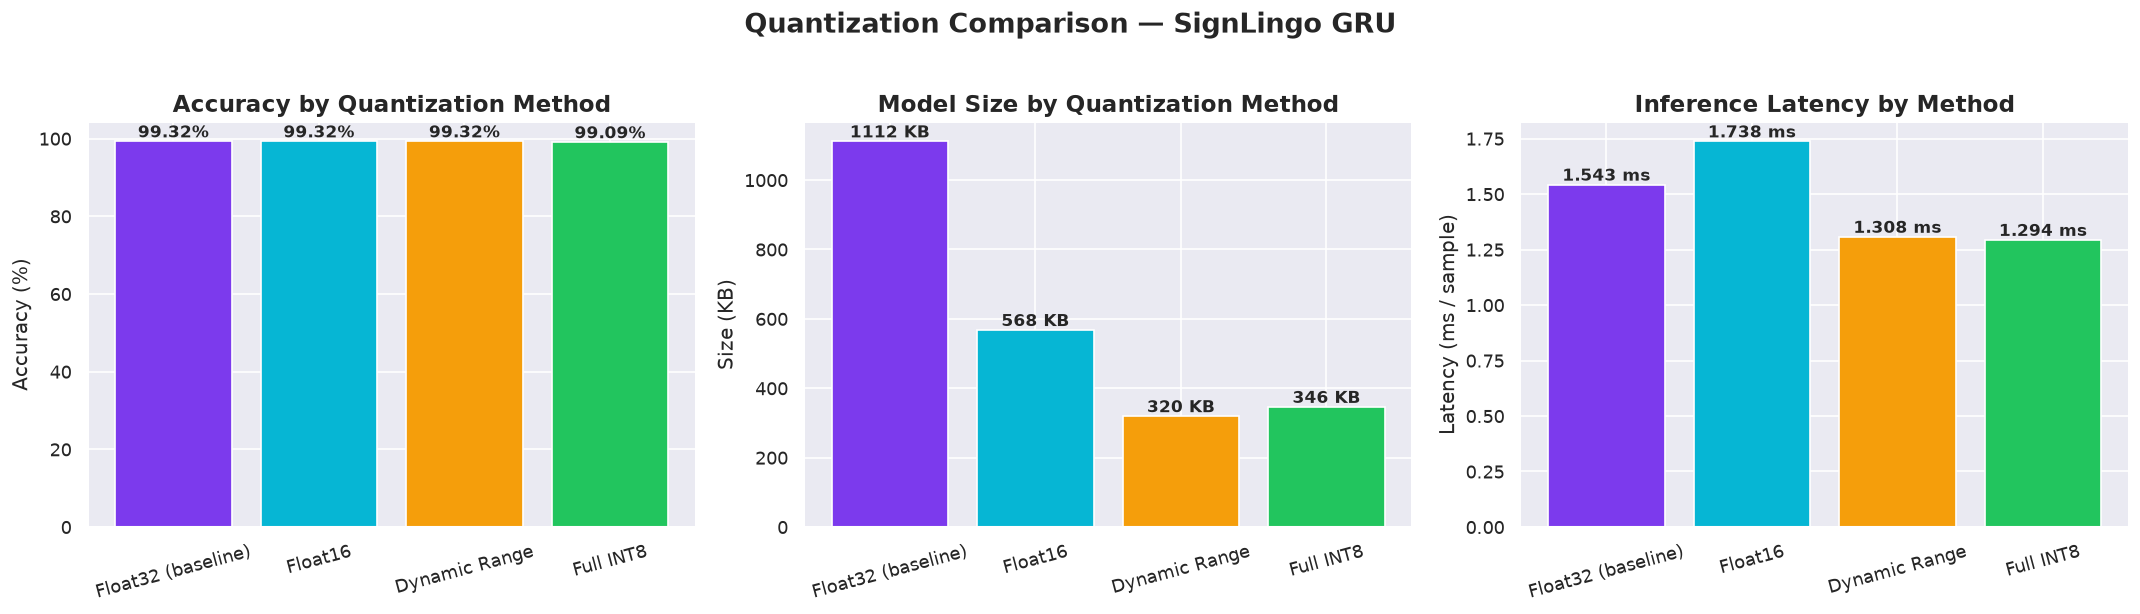

In [18]:
# ── D1: Side-by-side bar charts ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def _bar(ax, vals, title, ylabel, fmt="{:.1f}", suffix=""):
    bars = ax.bar(labels, vals, color=colors, edgecolor="white", linewidth=1)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.01,
                fmt.format(val) + suffix,
                ha="center", fontsize=10, fontweight="bold")
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=15)

_bar(axes[0], accs,  "Accuracy by Quantization Method",    "Accuracy (%)",         fmt="{:.2f}", suffix="%")
_bar(axes[1], sizes, "Model Size by Quantization Method",  "Size (KB)",            fmt="{:.0f}", suffix=" KB")
_bar(axes[2], lats,  "Inference Latency by Method",        "Latency (ms / sample)",fmt="{:.3f}", suffix=" ms")

plt.suptitle("Quantization Comparison — SignLingo GRU", fontsize=16,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

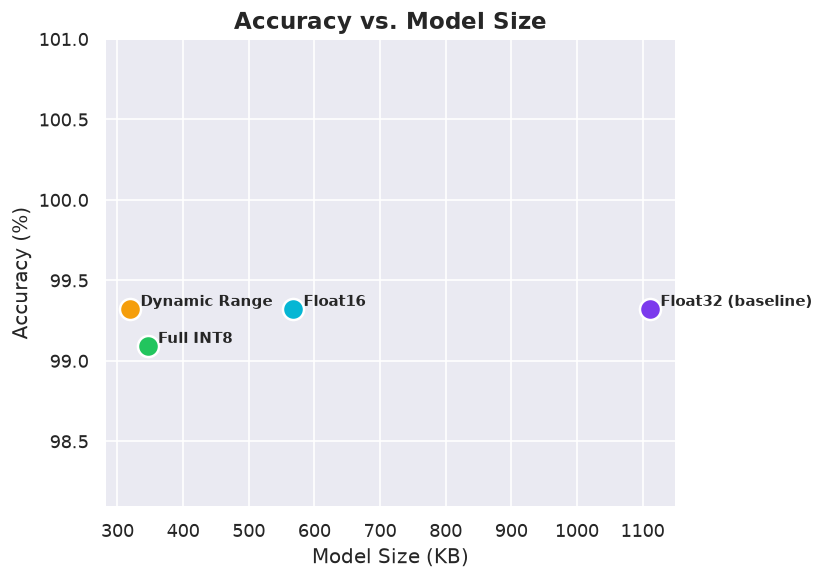

In [19]:
# ── D2: Accuracy vs. Size scatter ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for i, r in enumerate(results):
    ax.scatter(r["Size (KB)"], r["Accuracy (%)"],
               color=r["_color"], s=160, zorder=3, edgecolors="white", linewidths=1.5)
    ax.annotate(r["Model"],
                xy=(r["Size (KB)"], r["Accuracy (%)"]),
                xytext=(6, 2), textcoords="offset points",
                fontsize=9, fontweight="bold")

ax.set_xlabel("Model Size (KB)")
ax.set_ylabel("Accuracy (%)")
ax.set_title("Accuracy vs. Model Size", fontweight="bold")
acc_min = min(accs)
ax.set_ylim(acc_min - 1, 101)
plt.tight_layout()
plt.show()

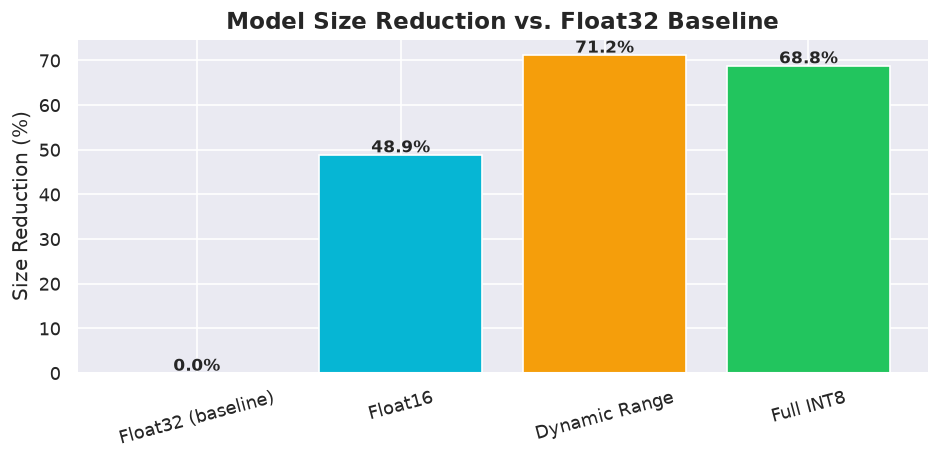

In [20]:
# ── D3: Size reduction bar chart (relative to FP32 baseline) ─────────────────
fp32_size = sizes[0]
reductions = [100 * (1 - s / fp32_size) for s in sizes]

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(labels, reductions,
              color=colors, edgecolor="white", linewidth=1)
for bar, val in zip(bars, reductions):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.5,
            f"{val:.1f}%", ha="center", fontsize=10, fontweight="bold")
ax.set_title("Model Size Reduction vs. Float32 Baseline", fontweight="bold")
ax.set_ylabel("Size Reduction (%)")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

In [21]:
# ── D4: Print final recommendation ───────────────────────────────────────────
# Pick the model with the highest accuracy that is still at most 5% below FP32.
fp32_acc = accs[0]
ACC_THRESHOLD = fp32_acc - 5.0   # tolerate up to 5 pp accuracy drop

candidates = [r for r in results if r["Accuracy (%)"] >= ACC_THRESHOLD]
# Among those, prefer the smallest
best = min(candidates, key=lambda r: r["Size (KB)"])

print("\n" + "=" * 60)
print("  RECOMMENDATION")
print("=" * 60)
print(f"  Best balance of accuracy & size: {best['Model']}")
print(f"    Accuracy : {best['Accuracy (%)']:.2f}%")
print(f"    Size     : {best['Size (KB)']:.0f} KB")
print(f"    Latency  : {best['Latency (ms/sample)']:.3f} ms/sample")
print(f"    File     : {best['_path']}")
print("=" * 60)


  RECOMMENDATION
  Best balance of accuracy & size: Dynamic Range
    Accuracy : 99.32%
    Size     : 320 KB
    Latency  : 1.308 ms/sample
    File     : signlingo_dynamic.tflite
